# Supervised Learning Algorithms

# KNN

# Naive Bayes

# Decision Tree

# Support Vector Machine (SVM)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.drop(['who', 'embark_town', 'deck', 'embark_town',
       'alive', 'class', 'adult_male'], axis=1, inplace=True)

In [5]:
df['age'].fillna(df['age'].mean(), inplace=True)

In [6]:
# as embarked has 889 not null rows, we are dropping 2 rows from the dataset

df.dropna(subset=['embarked'], inplace=True)

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [8]:
df['sex'] = le.fit_transform(df['sex'])
df['embarked'] = le.fit_transform(df['embarked'])

In [9]:
df = df.astype(int)

In [10]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22,1,0,7,2,0
1,1,1,0,38,1,0,71,0,0
2,1,3,0,26,0,0,7,2,1
3,1,1,0,35,1,0,53,2,0
4,0,3,1,35,0,0,8,2,1


In [11]:
X = df.drop('survived', axis=1)
y = df['survived']

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [13]:
X_scaled = scaler.fit_transform(X)

In [14]:
X_scaled

array([[ 0.82520863,  0.73534203, -0.57802333, ..., -0.49673282,
         0.58683958, -1.22934919],
       [-1.57221121, -1.35991138,  0.65537059, ...,  0.79153916,
        -1.93955453, -1.22934919],
       [ 0.82520863, -1.35991138, -0.26967485, ..., -0.49673282,
         0.58683958,  0.81343853],
       ...,
       [ 0.82520863, -1.35991138, -0.03841349, ..., -0.17466483,
         0.58683958, -1.22934919],
       [-1.57221121,  0.73534203, -0.26967485, ..., -0.03376008,
        -1.93955453,  0.81343853],
       [ 0.82520863,  0.73534203,  0.19284787, ..., -0.49673282,
        -0.67635748,  0.81343853]])

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

KNeighborsClassifier()

In [17]:
y_pred = model.predict(X_test)

In [18]:
# Model Evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
accu_sc = accuracy_score(y_test, y_pred)
accu_sc

0.797752808988764

In [20]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[89, 20],
       [16, 53]])

<Axes: >

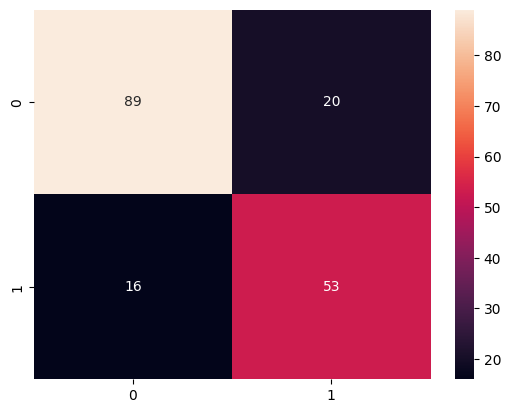

In [21]:
sns.heatmap(cm, annot=True, fmt='d')


In [22]:
clsf_report = classification_report(y_test, y_pred)
print(clsf_report)

              precision    recall  f1-score   support

           0       0.85      0.82      0.83       109
           1       0.73      0.77      0.75        69

    accuracy                           0.80       178
   macro avg       0.79      0.79      0.79       178
weighted avg       0.80      0.80      0.80       178



# Naive Bayes

Naive Bayes is a fast, efficient supervised machine learning algorithm for classification based on Bayes' Theorem, which predicts class probabilities by assuming independence between features

In [23]:
X2 = df.drop('survived', axis=1)
y2 = df['survived']

In [24]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [25]:
from sklearn.naive_bayes import GaussianNB

model2 = GaussianNB()
model2.fit(X2_train, y2_train)

GaussianNB()

In [26]:
y2_pred = model2.predict(X2_test)

In [27]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [28]:
accu_sc = accuracy_score(y2_test, y2_pred)
accu_sc

0.7752808988764045

In [29]:
class_report = classification_report(y2_test, y2_pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.85      0.77      0.81       109
           1       0.68      0.78      0.73        69

    accuracy                           0.78       178
   macro avg       0.77      0.78      0.77       178
weighted avg       0.78      0.78      0.78       178



In [30]:
cm = confusion_matrix(y2_test, y2_pred)
cm

array([[84, 25],
       [15, 54]])

# Decision Tree

A decision tree classifier is a supervised machine learning algorithm that uses a flowchart-like tree structure to classify data based on a series of feature-based rules. It works by recursively splitting a dataset into smaller subsets until each subset is sufficiently "pure" (contains items belonging mostly to the same class), at which point a final decision can be made at a leaf node.

In [31]:
# We will be using scaled data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [32]:
from sklearn.tree import DecisionTreeClassifier

model3 = DecisionTreeClassifier(random_state=42)

In [33]:
model3.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [34]:
y_pred = model3.predict(X_test)

In [35]:
accur_scr = accuracy_score(y_test, y_pred)
accur_scr

0.8033707865168539

In [36]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[89, 20],
       [15, 54]])

<Axes: >

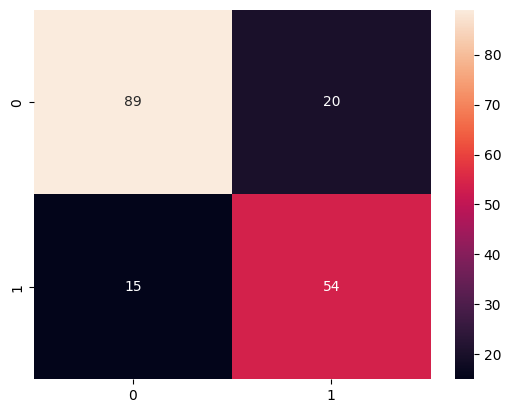

In [37]:
sns.heatmap(cm, annot=True, fmt='d')

In [38]:
classf_report = classification_report(y_test, y_pred)
print(classf_report)

              precision    recall  f1-score   support

           0       0.86      0.82      0.84       109
           1       0.73      0.78      0.76        69

    accuracy                           0.80       178
   macro avg       0.79      0.80      0.80       178
weighted avg       0.81      0.80      0.80       178



# Support Vector Machine (SVM)

Support Vector Machine (SVM) is a powerful supervised machine learning algorithm used for classification and regression tasks by finding the optimal hyperplane that maximizes the margin between data classes. It is effective for linear and non-linear data using the "kernel trick" to map data into higher-dimensional spaces.

In [39]:
from sklearn.svm import SVC

In [40]:
model_svm = SVC(kernel='rbf')
model_svm.fit(X_train, y_train)

SVC()

In [41]:
y_pred_scm = model_svm.predict(X_test)

In [42]:
accu_sc = accuracy_score(y_test, y_pred_scm)
accu_sc

0.8146067415730337

In [43]:
cm = confusion_matrix(y_test, y_pred_scm)
cm

array([[91, 18],
       [15, 54]])

<Axes: >

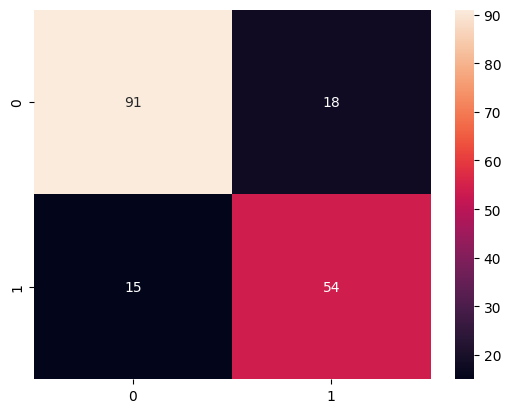

In [44]:
sns.heatmap(cm, annot=True, fmt='d')

In [45]:
classf_report = classification_report(y_test, y_pred_scm)
print(classf_report)

              precision    recall  f1-score   support

           0       0.86      0.83      0.85       109
           1       0.75      0.78      0.77        69

    accuracy                           0.81       178
   macro avg       0.80      0.81      0.81       178
weighted avg       0.82      0.81      0.82       178



# Cross Validation

In [46]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22,1,0,7,2,0
1,1,1,0,38,1,0,71,0,0
2,1,3,0,26,0,0,7,2,1
3,1,1,0,35,1,0,53,2,0
4,0,3,1,35,0,0,8,2,1


In [47]:
X = df.drop('survived', axis=1)
y = df['survived']

In [50]:
from sklearn.model_selection import cross_val_score

In [51]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [52]:
svm_model = SVC(kernel='rbf')

In [53]:
scores = cross_val_score(svm_model, X_scaled, y, cv=5, scoring='accuracy')

In [54]:
scores

array([0.83146067, 0.82022472, 0.81460674, 0.80898876, 0.86440678])

In [55]:
print(scores.mean())

0.8279375357074844


In [58]:
# For existin KNN model check scores

scores_knn = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')

In [59]:
scores_knn

array([0.78089888, 0.76404494, 0.8258427 , 0.81460674, 0.8079096 ])

In [62]:
print(scores_knn.mean())

0.7986605725893481


In [63]:
# Now lets use Grid Search CV

from sklearn.model_selection import GridSearchCV

In [ ]:
classifier = GridSearchCV(model, {
    'C': [1, 10, 20, 30],
    'kernel': ['rbf', 'linear', 'poly', 'sigmoid']
}, cv = 5, return_train_score = False)

In [64]:
classifier = GridSearchCV(model, {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}, cv = 5, return_train_score = False)

In [65]:
classifier.fit(X_scaled, y)


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']})

In [69]:
print("Best parameters for KNN:", classifier.best_params_)
print("Best score for KNN:", classifier.best_score_)


Best parameters for KNN: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Best score for KNN: 0.8155716371484797


In [70]:
results = pd.DataFrame(classifier.cv_results_)
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_metric,param_n_neighbors,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002998,0.001231,0.005713,0.002532,euclidean,3,uniform,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",0.775281,0.752809,0.814607,0.797753,0.813559,0.790802,0.023737,15
1,0.002266,0.000288,0.003316,0.000398,euclidean,3,distance,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",0.764045,0.752809,0.820225,0.780899,0.779661,0.779528,0.022855,20
2,0.001928,0.000048,0.004259,0.000421,euclidean,5,uniform,"{'metric': 'euclidean', 'n_neighbors': 5, 'wei...",0.780899,0.764045,0.825843,0.814607,0.807910,0.798661,0.022770,9
3,0.002052,0.000180,0.003279,0.000078,euclidean,5,distance,"{'metric': 'euclidean', 'n_neighbors': 5, 'wei...",0.769663,0.764045,0.820225,0.792135,0.774011,0.784016,0.020406,19
4,0.001994,0.000118,0.004388,0.000163,euclidean,7,uniform,"{'metric': 'euclidean', 'n_neighbors': 7, 'wei...",0.769663,0.769663,0.797753,0.797753,0.830508,0.793068,0.022545,14
5,0.002073,0.000228,0.003471,0.000225,euclidean,7,distance,"{'metric': 'euclidean', 'n_neighbors': 7, 'wei...",0.764045,0.775281,0.808989,0.786517,0.807910,0.788548,0.017738,16
6,0.001966,0.000091,0.006555,0.004149,euclidean,9,uniform,"{'metric': 'euclidean', 'n_neighbors': 9, 'wei...",0.786517,0.775281,0.786517,0.797753,0.836158,0.796445,0.021090,12
7,0.001942,0.000011,0.003615,0.000133,euclidean,9,distance,"{'metric': 'euclidean', 'n_neighbors': 9, 'wei...",0.775281,0.786517,0.803371,0.792135,0.819209,0.795302,0.014998,13
8,0.001971,0.000064,0.004711,0.000243,euclidean,11,uniform,"{'metric': 'euclidean', 'n_neighbors': 11, 'we...",0.780899,0.769663,0.808989,0.808989,0.858757,0.805459,0.030823,5
9,0.001863,0.000071,0.003695,0.000136,euclidean,11,distance,"{'metric': 'euclidean', 'n_neighbors': 11, 'we...",0.764045,0.786517,0.808989,0.797753,0.830508,0.797562,0.022188,10


In [71]:
results.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_metric', 'param_n_neighbors', 'param_weights', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score'],
      dtype='object')

In [72]:
results[['param_metric', 'param_n_neighbors', 'param_weights', 'mean_test_score']]

,param_metric,param_n_neighbors,param_weights,mean_test_score
0,euclidean,3,uniform,0.790802
1,euclidean,3,distance,0.779528
2,euclidean,5,uniform,0.798661
3,euclidean,5,distance,0.784016
4,euclidean,7,uniform,0.793068
5,euclidean,7,distance,0.788548
6,euclidean,9,uniform,0.796445
7,euclidean,9,distance,0.795302
8,euclidean,11,uniform,0.805459
9,euclidean,11,distance,0.797562
